In [ ]:
readme_text = """# Edge AI-Based IoT Threat Detection System

## 1. Project Overview
This project presents an Edge AI solution for real-time detection of IoT network threats.
A machine learning model is trained using structured network traffic data and deployed on a Raspberry Pi device for on-device inference.

The system is capable of identifying malicious traffic such as Distributed Denial of Service (DDoS) attacks and botnet activity.
The solution demonstrates a complete end-to-end pipeline including data preparation, model training, deployment, and real-time visualization.

---

## 2. Model Development Platform
The machine learning model was developed and trained using Google Colab, leveraging Python-based data science libraries.
The training process included data preprocessing, feature handling, and model evaluation using standard machine learning practices.

Technologies Used:
1. Python
2. Pandas, NumPy
3. Scikit-learn (Random Forest Classifier)

---

## 3. Dataset Description

The dataset used in this project consists of multiple CSV files containing extracted network traffic features.
These features represent statistical and protocol-level characteristics of IoT communication.

## Dataset Files:
1.train.csv - Used for training the machine learning model
2.validation.csv - Used for model validation and tuning
3.test.csv- Used for evaluating model performance
4.bot.csv - Contains botnet and malicious traffic samples

---

## 4. System Architecture
Two Raspberry Pi devices are used:

Raspberry Pi 1 (Detector Node):
i. Hosts the trained machine learning model
ii. Runs a Flask API for prediction
iii.Performs real-time classification of incoming traffic
iv. Hosts the Streamlit dashboard for visualization

Raspberry Pi 2 (Attacker / Traffic Generator Node):
i. Simulates IoT network traffic
ii. Generates feature vectors representing network behavior
iii. Sends data to the detector node over the network

Workflow:
Raspberry Pi (Attacker) → Network → Raspberry Pi (Detector) → Machine Learning Model → Dashboard Output

---
## 5. Features
Real-time IoT threat detection
Distributed system using **two Raspberry Pi devices**
Edge-based inference (on-device processing)
REST API-based communication (Flask)
Interactive dashboard for monitoring and visualization

## 6. Implementation Details
1. The dataset is processed and used to train a machine learning model in Google Colab
2. The trained model is exported and deployed on **Raspberry Pi 1 (Detector Node)**
3. A Flask-based API is implemented to handle prediction requests
4. Raspberry Pi 2, simulates network traffic and sends data to the detector
5. A Streamlit dashboard visualizes detection results in real time

This setup demonstrates a practical Edge AI deployment
where inference is performed locally on the device.

---

## 7. Notes
Edge Impulse was not used because the project uses structured tabular data
and requires a custom deployment pipeline using Flask and Raspberry Pi for real-time distributed detection.; instead, a custom machine learning pipeline was implemented using Google Colab and Scikit-learn.
The dataset included in this submission was used for training, validation, and testing of the model.
Model files and source code are not included as per submission requirements.
---

## 8. Conclusion
This project demonstrates a scalable and practical Edge AI solution for IoT security.
By utilizing two Raspberry Pi devices, the system simulates real-world distributed environments, enabling realistic testing of network-based attacks and real-time detection at the edge.
"""

with open("README.txt", "w") as f:
    f.write(readme_text)

In [ ]:
with open("README.txt", "w") as f:
    f.write(readme_text)

In [ ]:
from google.colab import files
files.download("README.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uplode Dataset


In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset -IOT.zip to dataset -IOT.zip


In [2]:
import zipfile

with zipfile.ZipFile("dataset -IOT.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import os
os.listdir()

['.config', 'dataset -IOT.zip', 'dataset -IOT', 'drive', 'sample_data']

Import libraries

In [4]:
import pandas as pd
import numpy as np

In [5]:
os.listdir("dataset -IOT")

['CICIOT23']

In [ ]:
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

Load all files

In [7]:


train_df = pd.read_csv("/content/dataset -IOT/CICIOT23/train/train.csv")
val_df = pd.read_csv("/content/dataset -IOT/CICIOT23/validation/validation.csv")
test_df = pd.read_csv("/content/dataset -IOT/CICIOT23/test/test.csv")
bot_df = pd.read_csv("/content/dataset -IOT/CICIOT23/bot.csv.csv")

Check the columns

In [8]:
print("TRAIN COLUMNS:")
print(train_df.columns)

print("\nVALIDATION COLUMNS:")
print(val_df.columns)

print("\nTEST COLUMNS:")
print(test_df.columns)

print("\nBOT-IOT COLUMNS:")
print(bot_df.columns)

TRAIN COLUMNS:
Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')

VALIDATION COLUMNS:
Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',


Check the columns


In [9]:
train_df.columns = train_df.columns.str.strip()
val_df.columns = val_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()
bot_df.columns = bot_df.columns.str.strip()

In [ ]:
print("TRAIN COLUMNS:")
print(train_df.columns)

print("\nBOT-IOT COLUMNS:")
print(bot_df.columns)

TRAIN COLUMNS:
Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')

BOT-IOT COLUMNS:
Index(['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev',
       'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP',
       'drate', 'srate', 'max', 'attack', 'category', 'subcategory'],
      dtype='object')


In [10]:
print("Label column is:", train_df.columns[-1])

Label column is: label


In [11]:
train_df[train_df.columns[-1]].value_counts()

,count
label,
DDoS-ICMP_Flood,848088
DDoS-UDP_Flood,637558
DDoS-TCP_Flood,528499
DDoS-PSHACK_Flood,481254
DDoS-SYN_Flood,478653
DDoS-RSTFINFlood,475441
DDoS-SynonymousIP_Flood,422083
DoS-UDP_Flood,390422
DoS-TCP_Flood,314174


In [12]:
train_df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [13]:
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_val = val_df.drop("label", axis=1)
y_val = val_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

In [14]:
X_bot = bot_df.drop(["attack", "category", "subcategory"], axis=1, errors="ignore")
y_bot = bot_df["attack"]

Confirm the split worked

In [15]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("X_bot shape:", X_bot.shape)
print("y_bot shape:", y_bot.shape)

X_train shape: (5491971, 46)
y_train shape: (5491971,)
X_val shape: (1176851, 46)
y_val shape: (1176851,)
X_test shape: (1176851, 46)
y_test shape: (1176851,)
X_bot shape: (733705, 16)
y_bot shape: (733705,)


Check data types

In [16]:
print(X_train.dtypes)
print(X_bot.dtypes)

flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
Min                float64
Max                float64
AVG                float64
S

Fill or remove missing values

In [17]:
X_train = X_train.dropna()
X_val = X_val.dropna()
X_test = X_test.dropna()
X_bot = X_bot.dropna()

labels after dropping rows:

In [18]:
y_train = y_train.loc[X_train.index]
y_val = y_val.loc[X_val.index]
y_test = y_test.loc[X_test.index]
y_bot = y_bot.loc[X_bot.index]

Encode text columns

In [19]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

for col in X_bot.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_bot[col] = le.fit_transform(X_bot[col].astype(str))

Train the first model

In [20]:
print(train_df.columns)

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [21]:
label = train_df.columns[-1]
print("Label column:", label)

Label column: label


In [22]:
print(bot_df.columns)

Index(['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev',
       'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP',
       'drate', 'srate', 'max', 'attack', 'category', 'subcategory'],
      dtype='object')


In [23]:
bot_df.columns[-1]

'subcategory'

In [24]:
bot_label = bot_df.columns[-1]

X_bot = bot_df.drop(columns=[bot_label])
y_bot = bot_df[bot_label]

In [25]:
# Train/Test
label = train_df.columns[-1]

X_train = train_df.drop(columns=[label])
y_train = train_df[label]

X_test = test_df.drop(columns=[label])
y_test = test_df[label]

# Bot dataset (separate)
bot_label = bot_df.columns[-1]

X_bot = bot_df.drop(columns=[bot_label])
y_bot = bot_df[bot_label]

Traing time and Model Performance

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

start = time.time()

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

end = time.time()

test_pred = model.predict(X_test)

print("Training Time:", end - start, "seconds")
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Validate and test

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Train on Bot-IoT too

In [ ]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bot, y_bot, test_size=0.3, random_state=42
)

bot_model = RandomForestClassifier(n_estimators=100, random_state=42)
bot_model.fit(Xb_train, yb_train)

yb_pred = bot_model.predict(Xb_test)
print("Bot-IoT Accuracy:", accuracy_score(yb_test, yb_pred))
print(classification_report(yb_test, yb_pred))

Bot-IoT Accuracy: 0.99998637057498
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        33
           1       1.00      1.00      1.00    220079

    accuracy                           1.00    220112
   macro avg       1.00      0.95      0.98    220112
weighted avg       1.00      1.00      1.00    220112



In [ ]:
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

Add Confusion Matrix

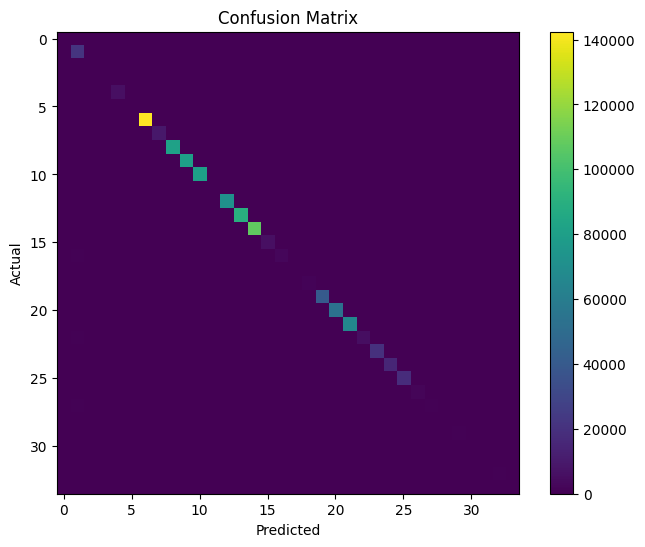

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compare Models

In [ ]:
rf_acc = accuracy_score(y_test, test_pred)
dt_acc = dt.score(X_test, y_test)
xgb_acc = xgb.score(X_test, y_test_encoded)

models = ['Random Forest', 'Decision Tree', 'XGBoost']
accuracy = [rf_acc, dt_acc, xgb_acc]

Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("DT Accuracy:", dt.score(X_test, y_test))

DT Accuracy: 0.9930528499996771


XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)
y_test_encoded = le_y.transform(y_test)

xgb = XGBClassifier()
xgb.fit(X_train, y_train_encoded)

print("XGB Accuracy:", xgb.score(X_test, y_test_encoded))

XGB Accuracy: 0.7965233038944938


Model Comparison

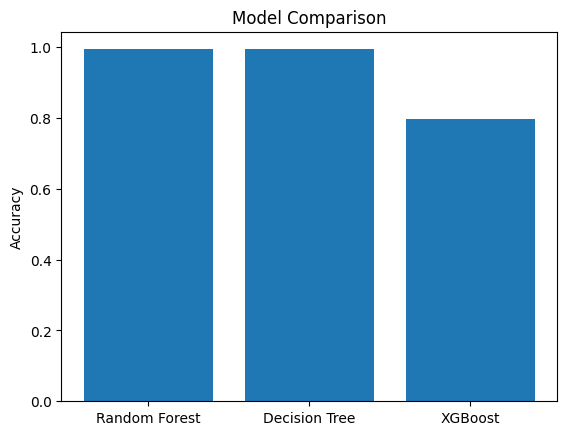

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Decision Tree', 'XGBoost']
accuracy = [0.9933, 0.9930, 0.7965]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

Show Feature Importance

          Feature  Importance
39            IAT    0.185376
1   Header_Length    0.054097
2   Protocol Type    0.048686
18      rst_count    0.041962
0   flow_duration    0.040618
38       Tot size    0.040597
35            Max    0.039656
41       Magnitue    0.037714
15      syn_count    0.037231
36            AVG    0.037173


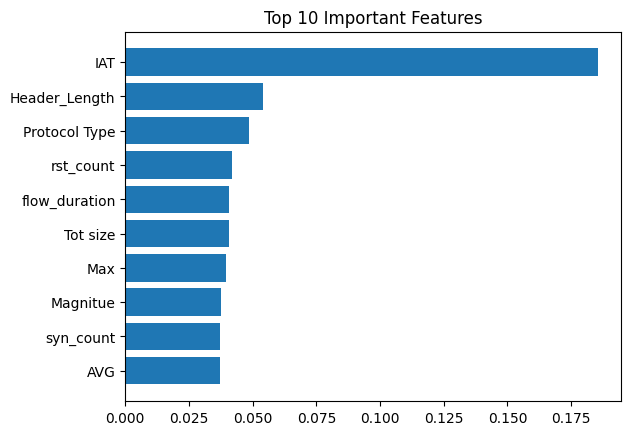

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Show top 10
print(importance_df.head(10))

# Plot
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

Get Train Model

In [ ]:
import joblib
from google.colab import files

# Save the trained model
joblib.dump(model, "iot_model.pkl")

# Download the saved model
files.download("iot_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/iot_model.pkl")

['/content/drive/MyDrive/iot_model.pkl']